# Homework 8


## References

+ Lectures 27-28 (inclusive).


## Instructions

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you should type them using latex. If you have never written latex before and you find it exceedingly difficult, we will likely accept handwritten solutions.
+ The total homework points are 100. Please note that the problems are not weighed equally.

In [1]:
MAKE_BOOK_FIGURES=True
import numpy as np
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

def set_book_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings
        'font.family': 'serif',  # For academic publishing
        'font.size': 8,  # As requested, 10pt font
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,  # Slightly smaller for better readability
        'ytick.labelsize': 7,
        'legend.fontsize': 7,

        # Line and marker settings for consistency
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,

        # Layout to prevent clipped labels
        'figure.constrained_layout.use': True,

        # Default DPI (will override when saving)
        'figure.dpi': 600,
        'savefig.dpi': 600,

        # Despine - remove top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,

        # Remove legend frame
        'legend.frameon': False,

        # Additional trim settings
        'figure.autolayout': True,  # Alternative to constrained_layout
        'savefig.bbox': 'tight',    # Trim when saving
        'savefig.pad_inches': 0.1   # Small padding to ensure nothing gets cut off
    })

def set_notebook_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings - using default sizes
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,

        # Line and marker settings
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,

        # Layout settings
        'figure.constrained_layout.use': True,

        # Remove only top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,

        # Remove legend frame
        'legend.frameon': False,

        # Additional settings
        'figure.autolayout': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

def save_for_book(fig, filename, is_vector=True, **kwargs):
    """
    Save a figure with book-optimized settings.

    Parameters:
    -----------
    fig : matplotlib figure
        The figure to save
    filename : str
        Filename without extension
    is_vector : bool
        If True, saves as vector at 1000 dpi. If False, saves as raster at 600 dpi.
    **kwargs : dict
        Additional kwargs to pass to savefig
    """
    # Set appropriate DPI and format based on figure type
    if is_vector:
        dpi = 1000
        ext = '.pdf'
    else:
        dpi = 600
        ext = '.tif'

    # Save the figure with book settings
    fig.savefig(f"{filename}{ext}", dpi=dpi, **kwargs)

def make_full_width_fig():
    return plt.subplots(figsize=(4.7, 2.9), constrained_layout=True)

def make_half_width_fig():
    return plt.subplots(figsize=(2.35, 1.45), constrained_layout=True)

if MAKE_BOOK_FIGURES:
    set_book_style()
else:
    set_notebook_style()

make_full_width_fig = make_full_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()
make_half_width_fig = make_half_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()

In [6]:
# Run this on Google colab
!pip install pyro-ppl

  Using cached pyro_ppl-1.9.1-py3-none-any.whl.metadata (7.8 kB)
  Using cached pyro_api-0.1.2-py3-none-any.whl.metadata (2.5 kB)
Using cached pyro_ppl-1.9.1-py3-none-any.whl (755 kB)
Using cached pyro_api-0.1.2-py3-none-any.whl (11 kB)


In [7]:
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import torch

## Problem 1  - Bayesian Linear regression on steroids

The purpose of this problem is to demonstrate that we have learned enough to do very complicated things.
In the first part, we will do Bayesian linear regression with radial basis functions (RBFs) in which we characterize the posterior of all parameters, including the length-scales of the RBFs.
In the second part, we are going to build a model that has an input-varying noise. Such models are called heteroscedastic models.

We need to write some `pytorch` code to compute the design matrix. This is absolutely necessary so that `pyro` can differentiate through all expressions.

In [9]:
class RadialBasisFunctions(torch.nn.Module):
    """Radial basis functions basis.

    Arguments:
    X   -  The centers of the radial basis functions.
    ell -  The assumed length scale.
    """
    def __init__(self, X, ell):
        super().__init__()
        self.X = X
        self.ell = ell
        self.num_basis = X.shape[0]
    def forward(self, x):
        distances = torch.cdist(x, self.X)
        return torch.exp(-.5 * distances ** 2 / self.ell ** 2)

Here is how you can use them:

In [10]:
# Make the basis
x_centers = torch.linspace(-1, 1, 10).unsqueeze(-1)
ell = 0.2
basis = RadialBasisFunctions(x_centers, ell)

# Some points (need to be N x 1)
x = torch.linspace(-1, 1, 100).unsqueeze(-1)

# Evaluate the basis
Phi = basis(x)

# Here is the shape of Phi
print(Phi.shape)

torch.Size([100, 10])


Here is how they look like:

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_680/2842066789.py:3: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(x, Phi[:, i], label=f"$\phi_{i}$")
/tmp/ipykernel_680/2842066789.py:4: SyntaxWarning: invalid escape sequence '\p'
  ax.set(xlabel="$x$", ylabel="$\phi(x)$")


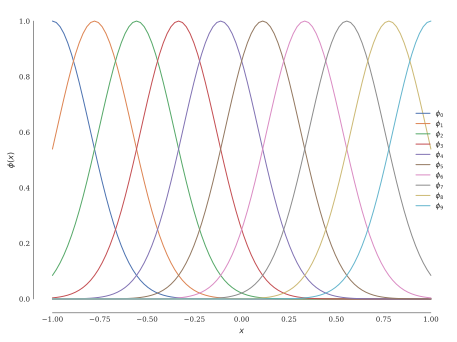

In [11]:
fig, ax = plt.subplots()
for i in range(Phi.shape[1]):
    ax.plot(x, Phi[:, i], label=f"$\phi_{i}$")
ax.set(xlabel="$x$", ylabel="$\phi(x)$")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True);

### Part A - Hierarchical Bayesian linear regression with input-independent noise

We will analyze the motorcycle dataset. The data is loaded below.

In [12]:
url = "https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/lecturebook/data/motor.dat"
!curl -LO $url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2970  100  2970    0     0  18319      0 --:--:-- --:--:-- --:--:-- 18447


We will work with the scaled data:

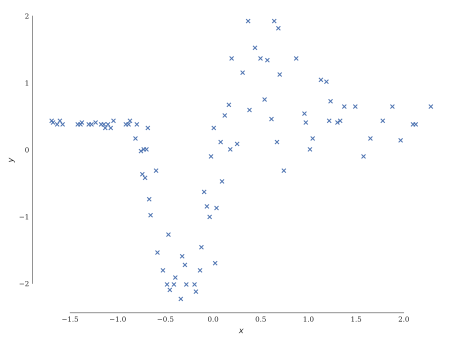

In [13]:
from sklearn.preprocessing import StandardScaler

data = np.loadtxt('motor.dat')
scaler = StandardScaler()
data = scaler.fit_transform(data)
X = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(-1)
Y = torch.tensor(data[:, 1], dtype=torch.float32)

fig, ax = plt.subplots()
ax.plot(X, Y, 'x')
ax.set(xlabel="$x$", ylabel="$y$")
sns.despine(trim=True);

### Part A.I

Your goal is to implement the model described below.
We use the radial basis functions (`RadialBasisFunction`) with centers, $x_i$ at $m=50$ equidistant points between the minimum and maximum of the observed inputs:

$$
\phi_i(x;\ell) = \exp \left( - \frac{(x - x_i)^2}{2 \ell^2} \right),
$$

for $i=1,\dots,m$.
We denote the vector of RBFs evaluated at $x$ as $\boldsymbol{\phi}(x;\ell)$.

We are not going to pick the length-scales $\ell$ by hand. Instead, we will put a prior on it:

$$
\ell \sim \text{Exponential}(1).
$$

The corresponding weights have priors:

$$
w_j | \alpha_i \sim N(0, \alpha_j^2),
$$

and its $\alpha_j$ has a prior:

$$
\alpha_j \sim \text{Exponential}(1),
$$

for $j=1,\dots,m$.

Denote our data as:

$$
x_{1:n} = (x_1, \dots, x_n)^T,\;\text{(inputs)},
$$

and

$$
y_{1:n} = (y_1, \dots, y_n)^T,\;\text{(outputs)}.
$$

The likelihood of the data is:

$$
y_i | \mathbf{w}, \sigma \sim N(\mathbf{w}^T \boldsymbol{\phi}(x_i;\ell), \sigma^2),
$$

for $i=1,\dots,n$.

$$
y_n | \ell, \mathbf{w}, \sigma \sim N(\mathbf{w}^T \boldsymbol{\phi}(x_n;\ell), \sigma^2).
$$

Complete the `pyro` implementation of that model:

**Answer:**

In [25]:
#Used AI for help with some parts of the code
def model(X, y, num_centers=50):
    with pyro.plate("centers", num_centers):
        alpha = pyro.sample("alpha", dist.Exponential(1.0))
        # Notice below that dist.Normal needs the standard deviation - not the variance
        # We follow a different convention in the lecture notes
        w = pyro.sample("w", dist.Normal(0.0, alpha))
    ell = pyro.sample("ell", dist.Exponential(1.0)) # Complete the code assign to ell the correct prior distribution (an Exponential(1)).
    # Hint: Look at alpha.
    sigma = pyro.sample("sigma", dist.Exponential(1.0)) # Complete the code assign to sigma the correct prior distribution (an Exponential(1))
    x_centers = torch.linspace(X.min(), X.max(), num_centers).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(X)
    with pyro.plate("data", X.shape[0]):
        pyro.sample("y", dist.Normal(Phi @ w, sigma), obs=y)
    # Notice that I'm making the model return all the variables that I have made.
    # This is not essential for characterizing the posterior, but it does reduce redundant code
    # when we are trying to get the posterior predictive.
    return locals()

The graph will help to understand the model:

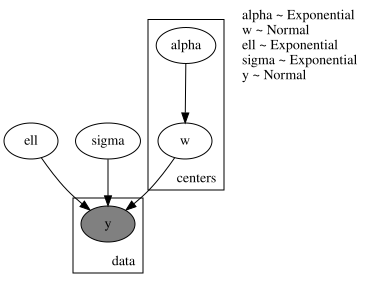

In [26]:
pyro.render_model(model, (X, Y), render_distributions=True)

Use `pyro.infer.autoguide.AutoDiagonalNormal` to make the guide:

In [27]:
guide = pyro.infer.autoguide.AutoDiagonalNormal(model)

We will use variational inference. Here is the training code from the hans-on activity:

In [28]:
def train(model, guide, data, num_iter=5_000):
    """Train a model with a guide.

    Arguments
    ---------
    model    -- The model to train.
    guide    -- The guide to train.
    data     -- The data to train the model with.
    num_iter -- The number of iterations to train.

    Returns
    -------
    elbos -- The ELBOs for each iteration.
    param_store -- The parameters of the model.
    """

    pyro.clear_param_store()

    optimizer = pyro.optim.Adam({"lr": 0.001})

    svi = pyro.infer.SVI(
        model,
        guide,
        optimizer,
        loss=pyro.infer.JitTrace_ELBO()
    )

    elbos = []
    for i in range(num_iter):
        loss = svi.step(*data)
        elbos.append(-loss)
        if i % 1_000 == 0:
            print(f"Iteration: {i} Loss: {loss}")

    return elbos, pyro.get_param_store()

### Part A.II

Train the model for 20,000 iterations. Call the `train()` function we defined above to do it.
Make sure you store the returned elbo values because you will need them later.

**Answer:**

In [29]:
# Your code here

elbos, params_store = train(model, guide, (X,Y), num_iter=20_000);

Iteration: 0 Loss: 333.41046142578125
Iteration: 1000 Loss: 230.93304443359375
Iteration: 2000 Loss: 173.7619171142578
Iteration: 3000 Loss: 149.47483825683594
Iteration: 4000 Loss: 130.12112426757812
Iteration: 5000 Loss: 126.30937194824219
Iteration: 6000 Loss: 135.9161834716797
Iteration: 7000 Loss: 121.11861419677734
Iteration: 8000 Loss: 124.99596405029297
Iteration: 9000 Loss: 142.11288452148438
Iteration: 10000 Loss: 124.92761993408203
Iteration: 11000 Loss: 134.0193634033203
Iteration: 12000 Loss: 125.86872100830078
Iteration: 13000 Loss: 130.39102172851562
Iteration: 14000 Loss: 126.36762237548828
Iteration: 15000 Loss: 132.01214599609375
Iteration: 16000 Loss: 114.64054107666016
Iteration: 17000 Loss: 124.53164672851562
Iteration: 18000 Loss: 126.4009017944336
Iteration: 19000 Loss: 123.7542495727539


### Part A.III

Plot the evolution of the ELBO.

**Answer:**

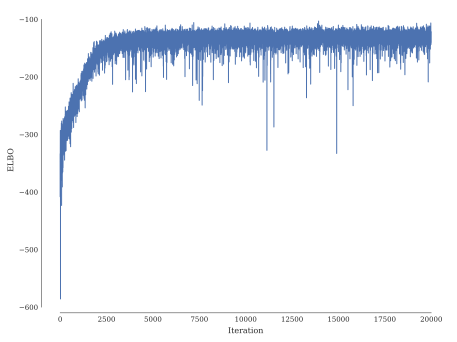

In [30]:
# Your code here
fig, ax = plt.subplots()
ax.plot(elbos)
ax.set(xlabel="Iteration", ylabel="ELBO")
sns.despine(trim=True)

### Part A.IV

Take 1,000 posterior samples.

**Answer:**

I'm giving you this one because it is a bit tricky. You need to use the `pyro.infer.Predictive` class to do it. Here is how you can use it:

In [31]:
post_samples = pyro.infer.Predictive(model, guide=guide, num_samples=1000)(X, Y)
# Just modify the call to get the right number of samples

### Part A.V

Plot the histograms of the posteriors of $\ell$, $\sigma$, $\alpha_{10}$ and $w_{10}$.

**Answer:**

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_680/2914122310.py:14: SyntaxWarning: invalid escape sequence '\e'
  ax.set(xlabel="$\ell$", ylabel="Frequency")
/tmp/ipykernel_680/2914122310.py:21: SyntaxWarning: invalid escape sequence '\e'
  axes[0, 0].set(xlabel="$\ell$", ylabel="Frequency", title="Length-scale $\ell$")
/tmp/ipykernel_680/2914122310.py:21: SyntaxWarning: invalid escape sequence '\e'
  axes[0, 0].set(xlabel="$\ell$", ylabel="Frequency", title="Length-scale $\ell$")
/tmp/ipykernel_680/2914122310.py:24

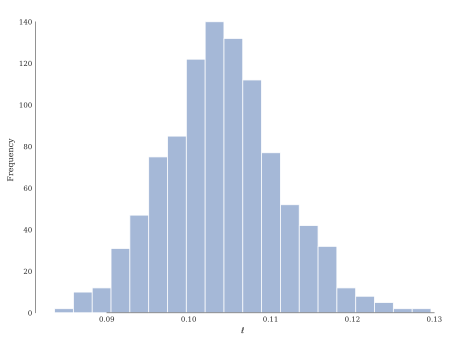

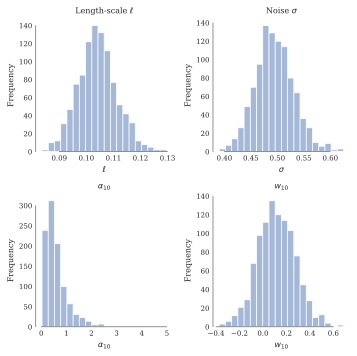

In [38]:
#Used AI for help with some parts of the code
# First, here is how to extract the samples.
ell = post_samples["ell"]
# You can do `post_samples.keys()` to see all the keys.
# But they should correspond to the names of the latent variables in the model.
sigma = post_samples["sigma"]
alphas = post_samples["alpha"]
ws = post_samples["w"]

# Here is the code to make the histogram for the length scale.
fig, ax = plt.subplots()
# **VERY IMPORTANT** - You need to detach the tensor from the computational graph.
# Otherwise, you will get very very strange behavior.
ax.hist(ell.detach().numpy(), bins=20, alpha=.5)
ax.set(xlabel="$\ell$", ylabel="Frequency")
sns.despine(trim=True);

# Your code for the other histograms here
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

axes[0, 0].hist(ell.detach().numpy(), bins=20, alpha=0.5)
axes[0, 0].set(xlabel="$\ell$", ylabel="Frequency", title="Length-scale $\ell$")

axes[0, 1].hist(sigma.detach().numpy(), bins=20, alpha=0.5)
axes[0, 1].set(xlabel="$\sigma$", ylabel="Frequency", title="Noise $\sigma$")

axes[1, 0].hist(alphas[:, 10].detach().numpy(), bins=20, alpha=0.5)
axes[1, 0].set(xlabel="$\\alpha_{10}$", ylabel="Frequency", title="$\\alpha_{10}$")

axes[1, 1].hist(ws[:, 10].detach().numpy(), bins=20, alpha=0.5)
axes[1, 1].set(xlabel="$w_{10}$", ylabel="Frequency", title="$w_{10}$")

plt.tight_layout()
sns.despine(trim=True)

### Part A.VI

Let's extend them model to make predictions.

**Answer:**

In [40]:
# Again, I'm giving you most of the code here.

def predictive_model(X, y, num_centers=50):
    # First we run the original model get all the variables
    params = model(X, y, num_centers)
    # Here is how you can access the variables
    w = params["w"]
    ell = params["ell"] # Access the length scale
    sigma = params["sigma"] # Access the standard deviation of the measurement noise
    x_centers = params["x_centers"] # Access the centers of the radial basis functions
    # Here are the points where we want to make predictions
    xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)
    # Evaluate the basis on the prediction points
    Phi = RadialBasisFunctions(x_centers, ell)(xs)
    # Make the predictions - we use a deterministic node here because we want to
    # save the results of the predictions.
    predictions = pyro.deterministic("predictions", Phi @ w)
    # Finally, we add the measurement noise
    predictions_with_noise = pyro.sample("predictions_with_noise", dist.Normal(predictions, sigma))
    return locals()

### Part A.VII

Extract the posterior predictive distribution using 10,000 samples. Separate aleatory and epistemic uncertainty.

**Answer:**

In [42]:
# Here is how to make the predictions. Just change the number of samples to the right number.
post_pred = pyro.infer.Predictive(predictive_model, guide=guide, num_samples=10_00)(X, Y)
# We will predict here:
xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)
# You can extract the predictions from post_pred like this:
predictions = post_pred["predictions"]
# Note that we extracted the deterministic node called "predictions" from the model.
# Get the epistemic uncertainty in the usual way:
p_500, p_025, p_975 = np.percentile(predictions, [50, 2.5, 97.5], axis=0)
# Extract predictions with noise
predictions_with_noise = post_pred["predictions_with_noise"].detach().numpy() # Your code here
# Get the aleatory uncertainty
ap_025, ap_975 = np.percentile(predictions_with_noise, [2.5, 97.5], axis=0) # Your code here

### Part A.VIII

Plot the data, the median, the 95% credible interval of epistemic uncertainty and the 95% credible interval of aleatory uncertainty, along with five samples from the posterior.

**Answer:**

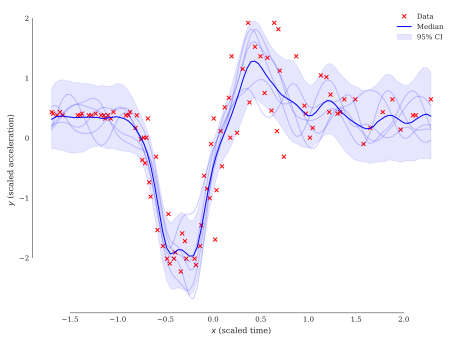

In [52]:
#Used AI for help with some parts of the code
param_samples = pyro.infer.Predictive(
    predictive_model,
    guide=guide,
    num_samples=1000
)(X,Y)

temps = torch.linspace(X.min(), X.max(), 100)
predictions = param_samples["predictions"]
pred_500, pred_025, pred_975 = predictions.quantile(torch.tensor([0.5, 0.025, 0.975]), dim=0)

fig, ax = plt.subplots()
ax.plot(X.squeeze(), Y, 'rx', label="Data")
ax.plot(xs.squeeze(), pred_500.squeeze(), 'b', label="Median")
ax.fill_between(xs.squeeze(), pred_025.squeeze(), pred_975.squeeze(), color='b', alpha=0.1, label="95% CI")

# Plot 5 posterior samples
for i in range(5):
    ax.plot(xs.squeeze(), predictions[i].squeeze(), 'b', alpha=0.2)

ax.set(xlabel="$x$ (scaled time)", ylabel="$y$ (scaled acceleration)")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True)

### Part B - Heteroscedastic regression

We are going to build a model that has an input-varying noise. Such models are called heteroscedastic models.
Here I will let you do more of the work.

Everything is as before for $\ell$, the $\alpha_j$'s, and the $w_j$'s.
We now introduce a model for the noise that is input dependent.
It will use the same RBFs as the mean function.
But let's use a different length-scale, $\ell_\sigma$.
So, we add:

$$
\ell_\sigma \sim \text{Exponential}(1),
$$

$$
\alpha_{\sigma,j} \sim \text{Exponential}(1),
$$

and

$$
w_{\sigma,j} | \alpha_{\sigma,j} \sim N(0, \alpha_{\sigma,j}^2),
$$

for $j=1,\dots,m$.

Our model for the input-dependent noise variance is:

$$
\sigma(x;\mathbf{w}_\sigma,\ell) = \exp\left(\mathbf{w}_\sigma^T \boldsymbol{\phi}(x;\ell_\sigma)\right).
$$

So, the likelihood of the data is:

$$
y_i | \mathbf{w}, \mathbf{w}_\sigma \sim N\left(\mathbf{w}^T \boldsymbol{\phi}(x_i;\ell), \sigma^2(x_i;\mathbf{w}_\sigma,\ell)\right),
$$

You will implement this model.

### Part B.I

Complete the code below:

In [53]:

#Used AI for help with some parts of the code
def model(X, y, num_centers=50):
    with pyro.plate("centers", num_centers):
        alpha = pyro.sample("alpha", dist.Exponential(1.0))
        w = pyro.sample("w", dist.Normal(0.0, alpha))
        # Let's add the generalized linear model for the log noise.
        alpha_noise = pyro.sample("alpha_noise", dist.Exponential(1.0))
        w_noise = pyro.sample("w_noise", dist.Normal(0.0, alpha_noise))
    ell = pyro.sample("ell", dist.Exponential(1.))
    ell_noise = pyro.sample("ell_noise", dist.Exponential(1.))
    x_centers = torch.linspace(X.min(), X.max(), num_centers).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(X)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(X)# Your code here
    # This is the new part 2/2
    model_mean = Phi @ w
    sigma = torch.exp(Phi_noise @ w_noise)# Your code here (torch.exp(<something>))
    with pyro.plate("data", X.shape[0]):
        pyro.sample("y", dist.Normal(model_mean, sigma), obs=y)
    return locals()

Make a `pyro.infer.autoguide.AutoDiagonalNormal` guide:

In [54]:
# Your code here
guide = pyro.infer.autoguide.AutoDiagonalNormal(model)
# Just modify the call to get the right number of samples

Make the graph of the model using `pyro` functionality:

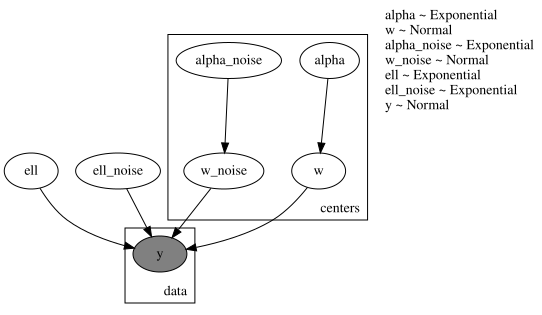

In [57]:
# Your code here

pyro.render_model(model, (X, Y), render_distributions=True)

### Part B.II

Train the model using 20,000 iterations. Then plot the evolution of the ELBO.

**Answer:**

Iteration: 0 Loss: 189.6046600341797
Iteration: 1000 Loss: 172.42860412597656
Iteration: 2000 Loss: 169.39523315429688
Iteration: 3000 Loss: 156.5724639892578
Iteration: 4000 Loss: 165.4246826171875
Iteration: 5000 Loss: 186.222900390625
Iteration: 6000 Loss: 198.76666259765625
Iteration: 7000 Loss: 191.54347229003906
Iteration: 8000 Loss: 160.50628662109375
Iteration: 9000 Loss: 162.9945068359375
Iteration: 10000 Loss: 193.4762420654297
Iteration: 11000 Loss: 153.6585235595703
Iteration: 12000 Loss: 154.74205017089844
Iteration: 13000 Loss: 168.74461364746094
Iteration: 14000 Loss: 160.19857788085938
Iteration: 15000 Loss: 155.27294921875
Iteration: 16000 Loss: 164.32325744628906
Iteration: 17000 Loss: 166.20701599121094
Iteration: 18000 Loss: 191.08834838867188
Iteration: 19000 Loss: 170.58486938476562


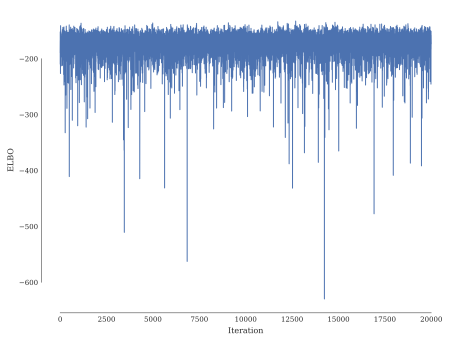

In [59]:
# Your code here

elbos, params_store = train(model, guide, (X,Y), num_iter=20_000);
# Your code here
fig, ax = plt.subplots()
ax.plot(elbos)
ax.set(xlabel="Iteration", ylabel="ELBO")
sns.despine(trim=True)


### Part B.III

Extend the model to make predictions.

**Answer:**

In [60]:
#Used AI for help with some parts of the code
def predictive_model(X, y, num_centers=50):
    params = model(X, y, num_centers)
    w = params["w"]
    w_noise = params["w_noise"]
    ell = params["ell"]
    ell_noise = params["ell_noise"]
    #sigma = # Your code here
    x_centers = params["x_centers"]
    xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(xs)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(xs)
    predictions = pyro.deterministic("predictions", Phi @ w)
    sigma = pyro.deterministic("sigma", torch.exp(Phi_noise @ w_noise))
    predictions_with_noise = pyro.sample("predictions_with_noise", dist.Normal(predictions, sigma))
    return locals()

### Part B.IV

Now, make predictions and calculate the epistemic and aleatory uncertainties as in part A.VII.

**Answer:**

In [61]:
# Your code here
#Used AI for help with some parts of the code
# Here is how to make the predictions. Just change the number of samples to the right number.
post_pred = pyro.infer.Predictive(predictive_model, guide=guide, num_samples=10_00)(X, Y)
# We will predict here:
xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)
# You can extract the predictions from post_pred like this:
predictions = post_pred["predictions"]
# Note that we extracted the deterministic node called "predictions" from the model.
# Get the epistemic uncertainty in the usual way:
p_500, p_025, p_975 = np.percentile(predictions, [50, 2.5, 97.5], axis=0)
# Extract predictions with noise
predictions_with_noise = post_pred["predictions_with_noise"].detach().numpy() # Your code here
# Get the aleatory uncertainty
ap_025, ap_975 = np.percentile(predictions_with_noise, [2.5, 97.5], axis=0) #

# Also extract the learned noise sigma to visualize how it varies with input
sigma_samples = post_pred["sigma"].detach().numpy()
sigma_500 = np.percentile(sigma_samples, 50, axis=0)



### Part B.V

Make the same plot as in part A.VIII.

**Answer:**

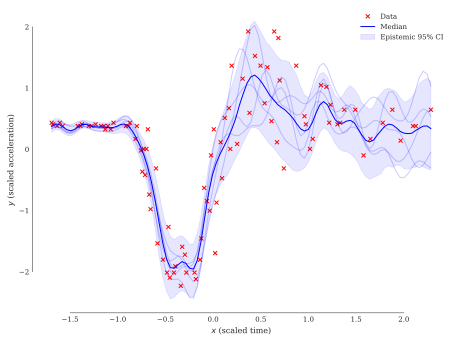

In [62]:
#Used mostly class notes
param_samples = pyro.infer.Predictive(
    predictive_model,
    guide=guide,
    num_samples=1000
)(X, Y)

xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)  # redefine to be safe
predictions = param_samples["predictions"].detach()
pred_500, pred_025, pred_975 = predictions.quantile(torch.tensor([0.5, 0.025, 0.975]), dim=0)

fig, ax = plt.subplots()
ax.plot(X.squeeze(), Y, 'rx', label="Data")
ax.plot(xs.squeeze(), pred_500.squeeze(), 'b', label="Median")
ax.fill_between(xs.squeeze(), pred_025.squeeze(), pred_975.squeeze(), color='b', alpha=0.1, label="Epistemic 95% CI")

# Plot 5 posterior samples
for i in range(5):
    ax.plot(xs.squeeze(), predictions[i].squeeze(), 'b', alpha=0.2)

ax.set(xlabel="$x$ (scaled time)", ylabel="$y$ (scaled acceleration)")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True)

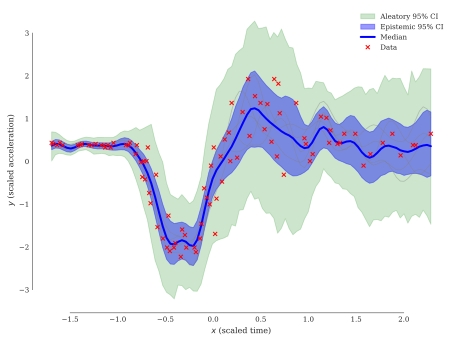

In [63]:
#Used AI for clarity and help with code
fig, ax = plt.subplots()

# Plot 5 posterior samples
for i in range(5):
    ax.plot(xs.squeeze(), predictions[i].squeeze(), color="gray", alpha=0.4, linewidth=0.8)

# Aleatory uncertainty (wider band)
ax.fill_between(xs.squeeze(), ap_025.squeeze(), ap_975.squeeze(),
                alpha=0.2, color="green", label="Aleatory 95% CI")

# Epistemic uncertainty (narrower band)
ax.fill_between(xs.squeeze(), p_025.squeeze(), p_975.squeeze(),
                alpha=0.4, color="blue", label="Epistemic 95% CI")

# Median prediction

ax.plot(xs.squeeze(), p_500.squeeze(), color="blue", linewidth=2, label="Median")

# Data
ax.plot(X.squeeze(), Y, 'x', color="red", label="Data")

ax.set(xlabel="$x$ (scaled time)", ylabel="$y$ (scaled acceleration)")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True)

### Part B.VI

Plot the estimated noise standard deviation as a function of of the input along with a 95% credible interval.

**Answer:**

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_680/4118431759.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(xs.squeeze(), s_500.squeeze(), 'b', label="Median $\sigma(x)$")
/tmp/ipykernel_680/4118431759.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set(xlabel="$x$ (scaled time)", ylabel="$\sigma(x)$",


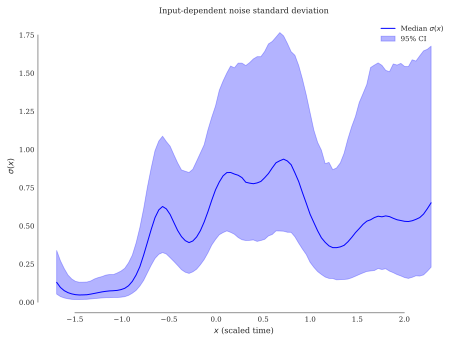

In [64]:
# Your code here
#Used AI for help with some parts of the code
sigma_samples = post_pred["sigma"].detach().numpy()
s_500, s_025, s_975 = np.percentile(sigma_samples, [50, 2.5, 97.5], axis=0)

fig, ax = plt.subplots()
ax.plot(xs.squeeze(), s_500.squeeze(), 'b', label="Median $\sigma(x)$")
ax.fill_between(xs.squeeze(), s_025.squeeze(), s_975.squeeze(),
                color='blue', alpha=0.3, label="95% CI")
ax.set(xlabel="$x$ (scaled time)", ylabel="$\sigma(x)$",
       title="Input-dependent noise standard deviation")
ax.legend(loc="best", frameon=False)
sns.despine(trim=True)

### Part B.VII

Which model do you prefer? Why?

**Answer:**
The heteroscedastic model (Part B) is better because the motorcycle data has a non-constant noise that is quiet before the crash, very noisy during impact.
Part A's fixed sigma is forced to use one noise value everywhere, so it's simultaneously too wide in quiet regions and too narrow in noisy ones. Part B learns a sigma(x) that adapts to the data, giving more honest uncertainty estimates throughout.
The extra complexity (more parameters) is worth it here because the varying noise is real and physically meaningful, not just overfitting.

### Part B.IX

Can you think of any way to improve the model?
Go crazy! This is the last homework assignment!
There is no right or wrong answer here.
But if you have a good idea, we will give you extra credit.


1. Adding a global shrinkage tau and local shrinkage lam per weight. This automatically stops irrelevant basis functions, acting as built-in feature selection.

2. Replacing Normal likelihood with StudentT with learned degrees of freedom nu Results in much more robust to outliers like the extreme acceleration spikes in the crash data.

3. Instead of fixed equidistant points, centers are treated as latent variables that adapt to where the data needs flexibility

Here are some way to improve the model -

Iteration: 0 Loss: 959.3539428710938
Iteration: 1000 Loss: 309.666259765625
Iteration: 2000 Loss: 232.71002197265625
Iteration: 3000 Loss: 222.8994140625
Iteration: 4000 Loss: 184.9766845703125
Iteration: 5000 Loss: 188.1647491455078
Iteration: 6000 Loss: 255.82179260253906
Iteration: 7000 Loss: 179.117431640625
Iteration: 8000 Loss: 177.95460510253906
Iteration: 9000 Loss: 169.00474548339844
Iteration: 10000 Loss: 172.4351806640625
Iteration: 11000 Loss: 151.519775390625
Iteration: 12000 Loss: 213.54824829101562
Iteration: 13000 Loss: 182.645263671875
Iteration: 14000 Loss: 195.41424560546875
Iteration: 15000 Loss: 156.74740600585938
Iteration: 16000 Loss: 175.1810760498047
Iteration: 17000 Loss: 194.4845733642578
Iteration: 18000 Loss: 183.40505981445312
Iteration: 19000 Loss: 172.49935913085938


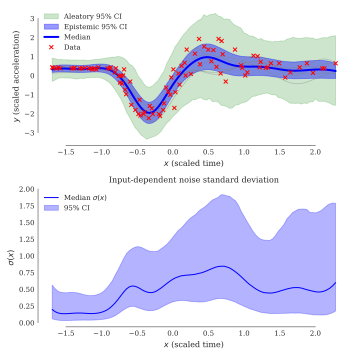

In [70]:
#Your code here
# Used AI for clarifying and help with code
from pyro.infer.autoguide import AutoNormalizingFlow
from pyro.distributions.transforms import iterated, block_autoregressive

def improved_model(X, y, num_centers=50):
    # ---- Improved priors using LogNormal instead of Exponential ----
    ell = pyro.sample("ell", dist.LogNormal(0., 1.))
    ell_noise = pyro.sample("ell_noise", dist.LogNormal(0., 1.))

    # ---- Learned RBF centers instead of fixed equidistant points ----
    x_centers = pyro.sample(
        "x_centers",
        dist.Normal(
            torch.linspace(X.min(), X.max(), num_centers),
            0.1 * torch.ones(num_centers)
        ).to_event(1)
    ).unsqueeze(-1)

    # ---- Horseshoe prior for weights ----
    tau = pyro.sample("tau", dist.HalfNormal(1.0))

    with pyro.plate("centers", num_centers):
        lam = pyro.sample("lam", dist.HalfNormal(1.0))
        alpha_noise = pyro.sample("alpha_noise", dist.LogNormal(0., 1.))
        w = pyro.sample("w", dist.Normal(0.0, tau * lam))
        w_noise = pyro.sample("w_noise", dist.Normal(0.0, alpha_noise))

    # ---- Design matrices ----
    Phi = RadialBasisFunctions(x_centers, ell)(X)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(X)

    model_mean = Phi @ w
    sigma = torch.exp(Phi_noise @ w_noise)

    # ---- Student-t likelihood for robustness to outliers ----
    nu = pyro.sample("nu", dist.Gamma(2.0, 0.1))

    with pyro.plate("data", X.shape[0]):
        pyro.sample("y", dist.StudentT(nu, model_mean, sigma), obs=y)

    return locals()


def improved_predictive_model(X, y, num_centers=50):
    params = improved_model(X, y, num_centers)
    w = params["w"]
    w_noise = params["w_noise"]
    ell = params["ell"]
    ell_noise = params["ell_noise"]
    nu = params["nu"]
    x_centers = params["x_centers"]

    xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)
    Phi = RadialBasisFunctions(x_centers, ell)(xs)
    Phi_noise = RadialBasisFunctions(x_centers, ell_noise)(xs)

    predictions = pyro.deterministic("predictions", Phi @ w)
    sigma = pyro.deterministic("sigma", torch.exp(Phi_noise @ w_noise))

    predictions_with_noise = pyro.sample(
        "predictions_with_noise",
        dist.StudentT(nu, predictions, sigma)
    )
    return locals()


# ---- Guide ----
guide = pyro.infer.autoguide.AutoDiagonalNormal(improved_model)

# ---- Train ----
elbos, param_store = train(improved_model, guide, (X, Y), num_iter=20_000)

# ---- Predictions ----
post_pred = pyro.infer.Predictive(
    improved_predictive_model, guide=guide, num_samples=10_000
)(X, Y)

xs = torch.linspace(X.min(), X.max(), 100).unsqueeze(-1)

predictions = post_pred["predictions"].detach().numpy()
p_500, p_025, p_975 = np.percentile(predictions, [50, 2.5, 97.5], axis=0)

predictions_with_noise = post_pred["predictions_with_noise"].detach().numpy()
ap_025, ap_975 = np.percentile(predictions_with_noise, [2.5, 97.5], axis=0)

sigma_samples = post_pred["sigma"].detach().numpy()
s_500, s_025, s_975 = np.percentile(sigma_samples, [50, 2.5, 97.5], axis=0)

# ---- Plot predictions ----
fig, axes = plt.subplots(2, 1, figsize=(5, 5))

for i in range(5):
    axes[0].plot(xs.squeeze(), predictions[i].squeeze(), color="gray", alpha=0.4, linewidth=0.8)
axes[0].fill_between(xs.squeeze(), ap_025.squeeze(), ap_975.squeeze(),
                      alpha=0.2, color="green", label="Aleatory 95% CI")
axes[0].fill_between(xs.squeeze(), p_025.squeeze(), p_975.squeeze(),
                      alpha=0.4, color="blue", label="Epistemic 95% CI")
axes[0].plot(xs.squeeze(), p_500.squeeze(), color="blue", linewidth=2, label="Median")
axes[0].plot(X.squeeze(), Y, 'x', color="red", label="Data")
axes[0].set(xlabel="$x$ (scaled time)", ylabel="$y$ (scaled acceleration)")
axes[0].legend(loc="best", frameon=False)

# ---- Plot learned sigma ----
axes[1].plot(xs.squeeze(), s_500.squeeze(), 'b', label=r"Median $\sigma(x)$")
axes[1].fill_between(xs.squeeze(), s_025.squeeze(), s_975.squeeze(),
                      color='blue', alpha=0.3, label="95% CI")
axes[1].set(xlabel="$x$ (scaled time)", ylabel=r"$\sigma(x)$",
            title="Input-dependent noise standard deviation")
axes[1].legend(loc="best", frameon=False)

plt.tight_layout()
sns.despine(trim=True)